<a href="https://colab.research.google.com/github/SakshyamAryal077/BASELINE-MODEL-ECG/blob/main/BestVersion2globalflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Imports.

In [25]:
import tensorflow as tf
from tensorflow.keras.layers import Add

from tensorflow.keras.layers import (
    Input, Conv1D, BatchNormalization, Activation,
    MaxPooling1D, Concatenate
)
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Concatenate



In [26]:
import numpy as np

X_train = np.load("X_train_smote.npy")
y_train = np.load("y_train_smote.npy")

X_test = np.load("X_testsmall.npy")
y_test = np.load("y_testsmall.npy")

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)


X_train shape: (108400, 360)
y_train shape: (108400,)
X_test shape: (6753, 360, 1)
y_test shape: (6753,)


In [27]:
if len(X_train.shape) == 2:
    X_train = np.expand_dims(X_train, axis=-1)

if len(X_test.shape) == 2:
    X_test = np.expand_dims(X_test, axis=-1)

print("After channel add:")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)


After channel add:
X_train shape: (108400, 360, 1)
X_test shape: (6753, 360, 1)


In [28]:
from tensorflow.keras.utils import to_categorical

num_classes = 5

y_train_cat = to_categorical(y_train, num_classes=num_classes)
y_test_cat = to_categorical(y_test, num_classes=num_classes)

print("y_train_cat shape:", y_train_cat.shape)
print("y_test_cat shape:", y_test_cat.shape)


y_train_cat shape: (108400, 5)
y_test_cat shape: (6753, 5)


In [29]:
print("Final training input shape:", X_train.shape)
print("Final training label shape:", y_train_cat.shape)
print("Final testing input shape:", X_test.shape)
print("Final testing label shape:", y_test_cat.shape)


Final training input shape: (108400, 360, 1)
Final training label shape: (108400, 5)
Final testing input shape: (6753, 360, 1)
Final testing label shape: (6753, 5)


### Step 1 - Stem Block (Changing for Experimentation)

In [30]:
def stem_block(x, filters=32, kernel_size=7):
    x = Conv1D(filters=filters, kernel_size=kernel_size, padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling1D(pool_size=2)(x)
    return x


Local Branches

In [31]:
def local_branch(x, filters=32):
    branch1 = Conv1D(filters=filters, kernel_size=3, padding='same')(x)
    branch1 = BatchNormalization()(branch1)
    branch1 = Activation('relu')(branch1)

    branch2 = Conv1D(filters=filters, kernel_size=5, padding='same')(x)
    branch2 = BatchNormalization()(branch2)
    branch2 = Activation('relu')(branch2)

    x = Concatenate()([branch1, branch2])
    return x


Global Branches

In [32]:
def global_branch(x, filters=32):
    branch1 = Conv1D(filters=filters, kernel_size=3, dilation_rate=2, padding='same')(x)
    branch1 = BatchNormalization()(branch1)
    branch1 = Activation('relu')(branch1)

    branch2 = Conv1D(filters=filters, kernel_size=3, dilation_rate=4, padding='same')(x)
    branch2 = BatchNormalization()(branch2)
    branch2 = Activation('relu')(branch2)

    x = Concatenate()([branch1, branch2])
    return x


In [33]:
inputs = Input(shape=(360, 1))

x = stem_block(inputs, filters=32, kernel_size=7)

local_feat = local_branch(x, filters=32)
global_feat = global_branch(x, filters=32)

x = Concatenate()([local_feat, global_feat])

model = Model(inputs, x)
model.summary()


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, 360, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_55 (Conv1D)  │ (None, 360, 32)   │        256 │ input_layer_7[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 360, 32)   │        128 │ conv1d_55[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_53       │ (None, 360, 32)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_7     │ (None, 180, 32)   │          0 │ activation_53[0]… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_56 (Conv1D)  │ (None, 180, 32)   │      3,104 │ max_pooling1d_7[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_57 (Conv1D)  │ (None, 180, 32)   │      5,152 │ max_pooling1d_7[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_58 (Conv1D)  │ (None, 180, 32)   │      3,104 │ max_pooling1d_7[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_59 (Conv1D)  │ (None, 180, 32)   │      3,104 │ max_pooling1d_7[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 180, 32)   │        128 │ conv1d_56[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 180, 32)   │        128 │ conv1d_57[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 180, 32)   │        128 │ conv1d_58[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 180, 32)   │        128 │ conv1d_59[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_54       │ (None, 180, 32)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_55       │ (None, 180, 32)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_56       │ (None, 180, 32)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_57       │ (None, 180, 32)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_21      │ (None, 180, 64)   │          0 │ activation_54[0]… │
│ (Concatenate)       │                   │            │ activation_55[0]… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 15,360 (60.00 KB)

 Trainable params: 15,040 (58.75 KB)

 Non-trainable params: 320 (1.25 KB)

Residual Blocks

In [34]:
def residual_block(x, filters=96, kernel_size=3):
    shortcut = x

    x = Conv1D(filters=filters, kernel_size=kernel_size, padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    x = Conv1D(filters=filters, kernel_size=kernel_size, padding='same')(x)
    x = BatchNormalization()(x)

    x = Add()([shortcut, x])
    x = Activation('relu')(x)

    return x


Test model with residual block added

In [35]:
input_shape = (360, 1)

inputs = Input(shape=input_shape)

x = stem_block(inputs, filters=32, kernel_size=7)

local_feat = local_branch(x, filters=32)
global_feat = global_branch(x, filters=32)

x = Concatenate()([local_feat, global_feat])
x = residual_block(x, filters=128, kernel_size=3)


model = Model(inputs, x)
model.summary()


Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_8       │ (None, 360, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_60 (Conv1D)  │ (None, 360, 32)   │        256 │ input_layer_8[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 360, 32)   │        128 │ conv1d_60[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_58       │ (None, 360, 32)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_8     │ (None, 180, 32)   │          0 │ activation_58[0]… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_61 (Conv1D)  │ (None, 180, 32)   │      3,104 │ max_pooling1d_8[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_62 (Conv1D)  │ (None, 180, 32)   │      5,152 │ max_pooling1d_8[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_63 (Conv1D)  │ (None, 180, 32)   │      3,104 │ max_pooling1d_8[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_64 (Conv1D)  │ (None, 180, 32)   │      3,104 │ max_pooling1d_8[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 180, 32)   │        128 │ conv1d_61[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 180, 32)   │        128 │ conv1d_62[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 180, 32)   │        128 │ conv1d_63[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 180, 32)   │        128 │ conv1d_64[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_59       │ (None, 180, 32)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_60       │ (None, 180, 32)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_61       │ (None, 180, 32)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_62       │ (None, 180, 32)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_24      │ (None, 180, 64)   │          0 │ activation_59[0]… │
│ (Concatenate)       │                   │            │ activation_60[0]… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 114,944 (449.00 KB)

 Trainable params: 114,112 (445.75 KB)

 Non-trainable params: 832 (3.25 KB)

SE attention block code

In [36]:
from tensorflow.keras.layers import GlobalAveragePooling1D, Dense, Reshape, Multiply


In [37]:
def se_block(x, reduction=16):
    filters = x.shape[-1]

    se = GlobalAveragePooling1D()(x)
    se = Dense(filters // reduction, activation='relu')(se)
    se = Dense(filters, activation='sigmoid')(se)
    se = Reshape((1, filters))(se)

    x = Multiply()([x, se])
    return x


In [38]:

input_shape = (360, 1)

inputs = Input(shape=input_shape)

x = stem_block(inputs, filters=32, kernel_size=7)

local_feat = local_branch(x, filters=32)
global_feat = global_branch(x, filters=32)

x = Concatenate()([local_feat, global_feat])
x = residual_block(x, filters=128, kernel_size=3)
x = se_block(x, reduction=16)

model = Model(inputs, x)
model.summary()


Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_9       │ (None, 360, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_67 (Conv1D)  │ (None, 360, 32)   │        256 │ input_layer_9[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 360, 32)   │        128 │ conv1d_67[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_65       │ (None, 360, 32)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_9     │ (None, 180, 32)   │          0 │ activation_65[0]… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_68 (Conv1D)  │ (None, 180, 32)   │      3,104 │ max_pooling1d_9[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_69 (Conv1D)  │ (None, 180, 32)   │      5,152 │ max_pooling1d_9[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_70 (Conv1D)  │ (None, 180, 32)   │      3,104 │ max_pooling1d_9[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_71 (Conv1D)  │ (None, 180, 32)   │      3,104 │ max_pooling1d_9[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 180, 32)   │        128 │ conv1d_68[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 180, 32)   │        128 │ conv1d_69[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 180, 32)   │        128 │ conv1d_70[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 180, 32)   │        128 │ conv1d_71[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_66       │ (None, 180, 32)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_67       │ (None, 180, 32)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_68       │ (None, 180, 32)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_69       │ (None, 180, 32)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_27      │ (None, 180, 64)   │          0 │ activation_66[0]… │
│ (Concatenate)       │                   │            │ activation_67[0]… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 117,128 (457.53 KB)

 Trainable params: 116,296 (454.28 KB)

 Non-trainable params: 832 (3.25 KB)

Add one more residual refinement block

In [39]:
input_shape = (360, 1)

inputs = Input(shape=input_shape)

x = stem_block(inputs, filters=32, kernel_size=7)

local_feat = local_branch(x, filters=32)
global_feat = global_branch(x, filters=32)

x = Concatenate()([local_feat, global_feat])
x = residual_block(x, filters=128, kernel_size=3)
x = se_block(x, reduction=16)
x = residual_block(x, filters=128, kernel_size=3)

model = Model(inputs, x)
model.summary()


Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_10      │ (None, 360, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_74 (Conv1D)  │ (None, 360, 32)   │        256 │ input_layer_10[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 360, 32)   │        128 │ conv1d_74[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_72       │ (None, 360, 32)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_10    │ (None, 180, 32)   │          0 │ activation_72[0]… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_75 (Conv1D)  │ (None, 180, 32)   │      3,104 │ max_pooling1d_10… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_76 (Conv1D)  │ (None, 180, 32)   │      5,152 │ max_pooling1d_10… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_77 (Conv1D)  │ (None, 180, 32)   │      3,104 │ max_pooling1d_10… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_78 (Conv1D)  │ (None, 180, 32)   │      3,104 │ max_pooling1d_10… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 180, 32)   │        128 │ conv1d_75[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 180, 32)   │        128 │ conv1d_76[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 180, 32)   │        128 │ conv1d_77[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 180, 32)   │        128 │ conv1d_78[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_73       │ (None, 180, 32)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_74       │ (None, 180, 32)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_75       │ (None, 180, 32)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_76       │ (None, 180, 32)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_30      │ (None, 180, 64)   │          0 │ activation_73[0]… │
│ (Concatenate)       │                   │            │ activation_74[0]… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 216,712 (846.53 KB)

 Trainable params: 215,368 (841.28 KB)

 Non-trainable params: 1,344 (5.25 KB)

Add classifier head

In [40]:
from tensorflow.keras.layers import GlobalAveragePooling1D, Dropout


In [41]:
from tensorflow.keras.layers import Dense

num_classes = 5   # change if needed

inputs = Input(shape=(360, 1))


x = stem_block(inputs, filters=32, kernel_size=7)

local_feat = local_branch(x, filters=32)
global_feat = global_branch(x, filters=32)

x = Concatenate()([local_feat, global_feat])
x = residual_block(x, filters=128, kernel_size=3)
x = se_block(x, reduction=16)
x = residual_block(x, filters=128, kernel_size=3)

x = GlobalAveragePooling1D()(x)
x = Dropout(0.3)(x)
x = Dense(64, activation='relu')(x)
outputs = Dense(num_classes, activation='softmax')(x)

model = Model(inputs, outputs)
model.summary()


Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_11      │ (None, 360, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_83 (Conv1D)  │ (None, 360, 32)   │        256 │ input_layer_11[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 360, 32)   │        128 │ conv1d_83[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_81       │ (None, 360, 32)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_11    │ (None, 180, 32)   │          0 │ activation_81[0]… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_84 (Conv1D)  │ (None, 180, 32)   │      3,104 │ max_pooling1d_11… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_85 (Conv1D)  │ (None, 180, 32)   │      5,152 │ max_pooling1d_11… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_86 (Conv1D)  │ (None, 180, 32)   │      3,104 │ max_pooling1d_11… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_87 (Conv1D)  │ (None, 180, 32)   │      3,104 │ max_pooling1d_11… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 180, 32)   │        128 │ conv1d_84[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 180, 32)   │        128 │ conv1d_85[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 180, 32)   │        128 │ conv1d_86[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 180, 32)   │        128 │ conv1d_87[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_82       │ (None, 180, 32)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_83       │ (None, 180, 32)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_84       │ (None, 180, 32)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_85       │ (None, 180, 32)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_33      │ (None, 180, 64)   │          0 │ activation_82[0]… │
│ (Concatenate)       │                   │            │ activation_83[0]… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 225,293 (880.05 KB)

 Trainable params: 223,949 (874.80 KB)

 Non-trainable params: 1,344 (5.25 KB)

One Hot Encoding before the Focal Loss.

In [42]:
from tensorflow.keras.utils import to_categorical

num_classes = 5

y_train = to_categorical(y_train, num_classes=num_classes)
y_test = to_categorical(y_test, num_classes=num_classes)


Focal loss Block

In [43]:
import tensorflow as tf

def focal_loss(gamma=2.0, alpha=1.0):
    def loss_fn(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        epsilon = tf.keras.backend.epsilon()
        y_pred = tf.clip_by_value(y_pred, epsilon, 1.0 - epsilon)

        cross_entropy = -y_true * tf.math.log(y_pred)
        weight = alpha * tf.pow(1 - y_pred, gamma)
        loss = weight * cross_entropy

        return tf.reduce_sum(loss, axis=1)
    return loss_fn


Compiling

In [44]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=focal_loss(gamma=2.0, alpha=1.0),
    metrics=['accuracy']
)


Add Callbacks

In [45]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        verbose=1
    )
]


Train.

In [46]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=30,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/30
1694/1694 ━━━━━━━━━━━━━━━━━━━━ 39s 15ms/step - accuracy: 0.8578 - loss: 0.1817 - val_accuracy: 0.8458 - val_loss: 0.1748 - learning_rate: 0.0010
Epoch 2/30
1694/1694 ━━━━━━━━━━━━━━━━━━━━ 28s 11ms/step - accuracy: 0.9306 - loss: 0.0763 - val_accuracy: 0.9069 - val_loss: 0.1299 - learning_rate: 0.0010
Epoch 3/30
1694/1694 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - accuracy: 0.9473 - loss: 0.0557 - val_accuracy: 0.8241 - val_loss: 0.1994 - learning_rate: 0.0010
Epoch 4/30
1694/1694 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - accuracy: 0.9563 - loss: 0.0439 - val_accuracy: 0.8424 - val_loss: 0.1671 - learning_rate: 0.0010
Epoch 5/30
1694/1694 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - accuracy: 0.9636 - loss: 0.0359 - val_accuracy: 0.9574 - val_loss: 0.0623 - learning_rate: 0.0010
Epoch 6/30
1694/1694 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - accuracy: 0.9674 - loss: 0.0315 - val_accuracy: 0.8235 - val_loss: 0.1626 - learning_rate: 0.0010
Epoch 7/30
1694/1694 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - accura

In [47]:
import numpy as np

y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test_cat, axis=1)


212/212 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step


In [48]:
from sklearn.metrics import classification_report, confusion_matrix

class_names = ['F', 'N', 'Q', 'S', 'V']

print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred))


Classification Report:
              precision    recall  f1-score   support

           F       0.72      0.92      0.81        48
           N       0.99      0.98      0.98      5421
           Q       0.87      0.91      0.89       683
           S       0.84      0.81      0.83       167
           V       0.94      0.95      0.95       434

    accuracy                           0.96      6753
   macro avg       0.87      0.91      0.89      6753
weighted avg       0.97      0.96      0.97      6753

Confusion Matrix:
[[  44    1    0    0    3]
 [  13 5303   75   23    7]
 [   0   49  619    2   13]
 [   0   24    5  136    2]
 [   4    3   12    1  414]]


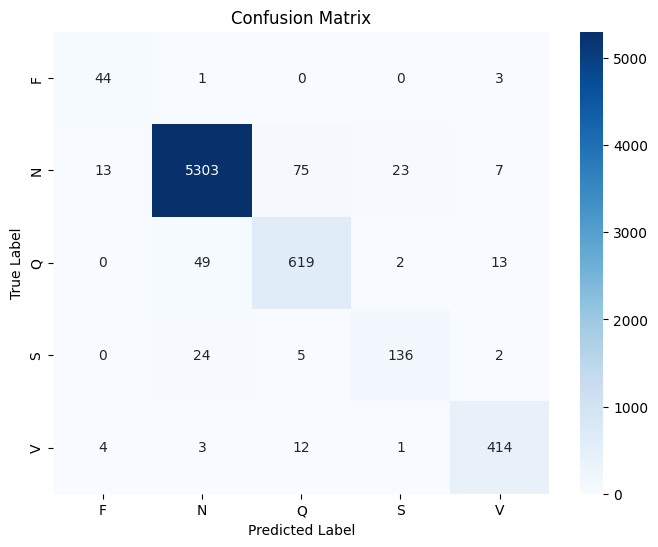

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


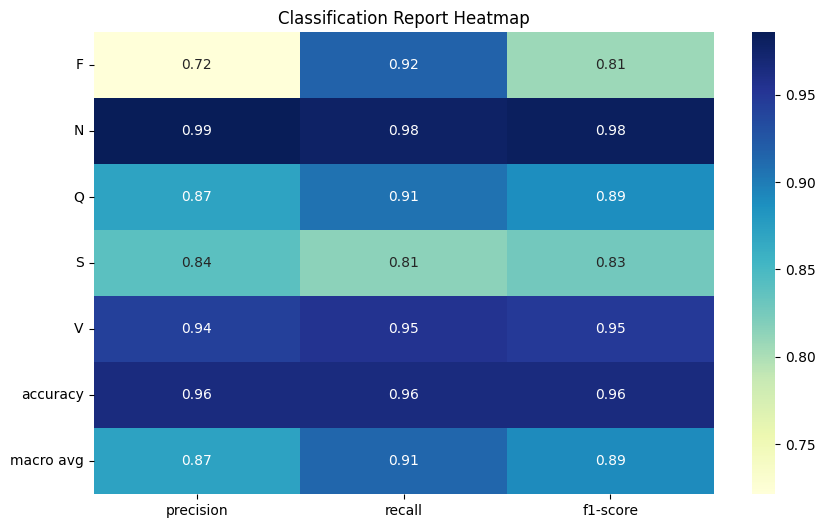

In [50]:
import pandas as pd

report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
report_df = pd.DataFrame(report).transpose()

plt.figure(figsize=(10, 6))
sns.heatmap(report_df.iloc[:-1, :-1], annot=True, cmap='YlGnBu', fmt=".2f")
plt.title("Classification Report Heatmap")
plt.show()


In [56]:
model.save("version1_ecg_model.keras")


In [57]:
model.save_weights("Version2globallocal.weights.h5")
